In [66]:
import pandas as pd
df_employment = pd.read_csv('./data/quasi-employment.csv')
df_groupon = pd.read_csv('./data/quasi-groupon.csv')
df_smoker = pd.read_csv('./data/quasi-smoker.csv')

## Difference-in-Difference Test

In [67]:
df_employment.groupby('state').size()

state
0     75
1    309
dtype: int64

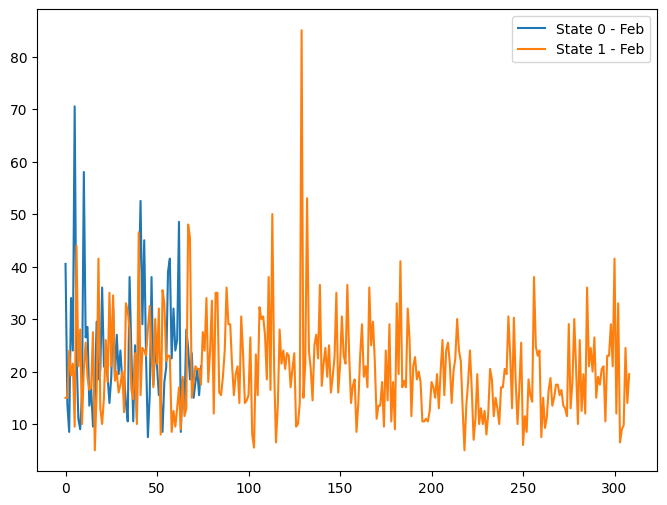

In [68]:
import matplotlib.pyplot as plt
df_emp_0 = df_employment[df_employment['state']==0].reset_index(drop=True)
df_emp_1 = df_employment[df_employment['state']==1].reset_index(drop=True)
plt.figure(figsize=(8,6))
plt.plot(df_emp_0.index, df_emp_0['total_emp_feb'], label='State 0 - Feb')
plt.plot(df_emp_1.index, df_emp_1['total_emp_feb'], label='State 1 - Feb')
plt.legend()
plt.show()

In [69]:
# make to long table
df_long = df_employment.melt(
    id_vars='state',
    value_vars=['total_emp_feb','total_emp_nov'],
    var_name='period',
    value_name='employment'
)
print(df_long.head())

   state         period  employment
0      0  total_emp_feb       40.50
1      0  total_emp_feb       13.75
2      0  total_emp_feb        8.50
3      0  total_emp_feb       34.00
4      0  total_emp_feb       24.00


In [70]:
import numpy as np
df_long['treated'] = (df_long['state']==1).astype(int)
df_long['post'] = (df_long['period']=='total_emp_nov').astype(int)
df_long['treated_post'] = df_long['treated'] * df_long['post']
# run did regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
X = df_long[['treated','post','treated_post']]
y = df_long['employment']
lr.fit(X, y)
y_pred = lr.predict(X)
residuals = y - y_pred
n = X.shape[0]
p = X.shape[1]
rss = np.sum(residuals ** 2)
sigma2 = rss / (n - p)
X_mat = np.column_stack([np.ones(len(X)),X])
cov_matrix = sigma2 * np.linalg.inv(X_mat.T @ X_mat)
se = np.sqrt(np.diag(cov_matrix))
coefs = np.concatenate([[lr.intercept_],lr.coef_])
t_stats = coefs / se
from scipy.stats import t
df_degree = n - p - 1
p_values = 2 * (1 - t.cdf(np.abs(t_stats), df=df_degree))
print("Coefficients:", coefs, "Standard Errors:", se, "T-stats:", t_stats, "P-values:", p_values)

Coefficients: [23.38       -2.94941748 -2.28333333  2.75      ] Standard Errors: [1.09755677 1.22352645 1.55217966 1.73032771] T-stats: [21.30185947 -2.41058742 -1.47104964  1.58929432] P-values: [0.         0.01616203 0.14168943 0.11240767]


1. treated coef is significant, whoing baseline difference is strong between groups
2. post has no strong over time trend across all groups, meaning overall market level did not significantly change
3. treated_post is not statistically significant, could mean (treue effect small, smaple size small, high variance, poor control group, parallel trend violated)
4. before DiD, need do parallet trend assumption

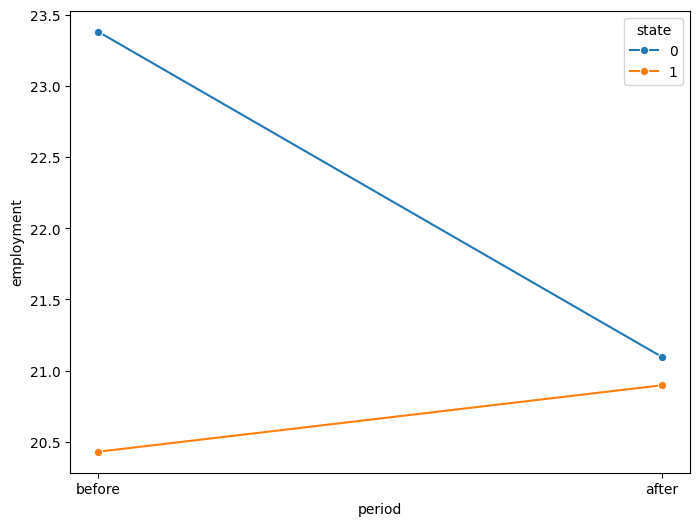

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
plot_df = df_long.groupby(['post','state'])['employment'].mean().reset_index()
plot_df['period'] = plot_df['post'].map({
    0: 'before',
    1: 'after'
})
plt.figure(figsize=(8,6))
sns.lineplot(data=plot_df, x='period', y='employment', hue='state', marker='o')
plt.show()

In Difference-in-Differences models, a low R² is not necessarily problematic because the objective is causal identification rather than predictive accuracy. What matters more is whether the treatment interaction coefficient is statistically significant, economically meaningful, and supported by valid assumptions such as parallel trends.

In [72]:
# confidence interval, use when p_value is not too low, CI can give a range
t_crit = t.ppf(1 - 0.05/2, df=n-p-1)
lower = coefs - t_crit * se
upper = coefs + t_crit * se
print("95% Confidence Intervals:")
for i in range(len(coefs)):
    print(f"Coef {i}: [{lower[i]:.4f}, {upper[i]:.4f}]")

95% Confidence Intervals:
Coef 0: [21.2254, 25.5346]
Coef 1: [-5.3513, -0.5475]
Coef 2: [-5.3304, 0.7637]
Coef 3: [-0.6468, 6.1468]


## Propensity Score: predict receiving treatment probability

In [73]:
df_groupon.shape
df_groupon.info()
df_groupon.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   deal_id          710 non-null    object
 1   start_date       710 non-null    object
 2   min_req          710 non-null    int64 
 3   treatment        710 non-null    int64 
 4   prom_length      710 non-null    int64 
 5   price            710 non-null    int64 
 6   discount_pct     710 non-null    int64 
 7   coupon_duration  710 non-null    int64 
 8   featured         710 non-null    int64 
 9   limited_supply   710 non-null    int64 
 10  fb_likes         710 non-null    int64 
 11  quantity_sold    710 non-null    int64 
 12  revenue          710 non-null    int64 
dtypes: int64(11), object(2)
memory usage: 72.2+ KB


,min_req,treatment,prom_length,price,discount_pct,coupon_duration,featured,limited_supply,fb_likes,quantity_sold,revenue
count,710.000000,710.000000,710.000000,710.000000,710.000000,710.00000,710.000000,710.000000,710.000000,710.000000,710.000000
mean,8.759155,0.304225,3.678873,35.300000,53.061972,106.86338,0.116901,0.829577,88.669014,386.652113,10642.701408
std,27.880963,0.460403,1.323959,36.356624,8.190716,128.15513,0.321529,0.376269,150.282551,663.358446,18131.366995
min,1.000000,0.000000,2.000000,5.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,3.000000,15.000000,50.000000,11.00000,0.000000,1.000000,17.000000,70.000000,1565.000000
50%,1.000000,0.000000,3.000000,24.000000,51.000000,75.00000,0.000000,1.000000,40.500000,190.000000,5000.000000
75%,5.000000,1.000000,4.000000,39.000000,56.000000,185.00000,0.000000,1.000000,99.000000,480.000000,12450.000000
max,300.000000,1.000000,9.000000,299.000000,85.000000,1812.00000,1.000000,1.000000,1596.000000,5000.000000,210000.000000


<Axes: >

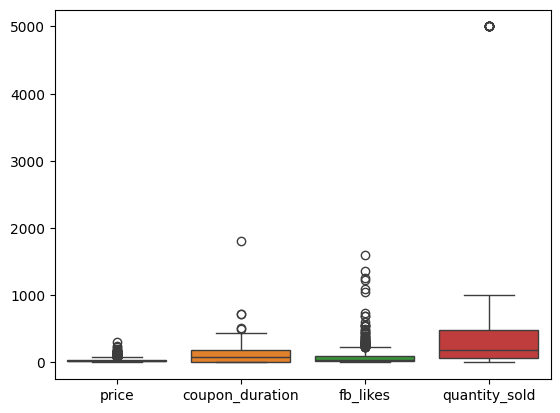

In [74]:
sns.boxplot(data=df_groupon[['price','coupon_duration','fb_likes','quantity_sold']])

<Axes: >

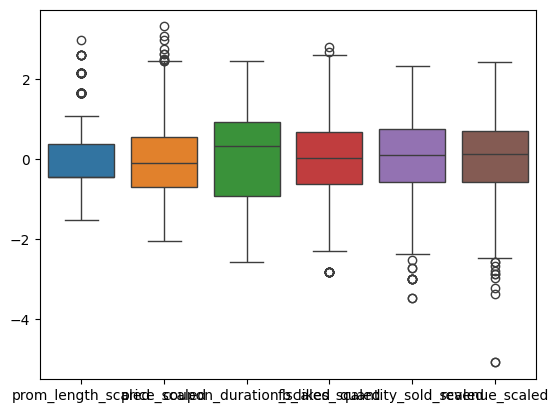

In [75]:
update_cols = ['prom_length','price','coupon_duration','fb_likes','quantity_sold','revenue']
for col in update_cols:
    df_groupon[col + '_log'] = np.log1p(df_groupon[col])
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_groupon[[col + '_scaled' for col in update_cols]] = scaler.fit_transform(df_groupon[[col + '_log' for col in update_cols]])
sns.boxplot(data=df_groupon[[col + '_scaled' for col in update_cols]])

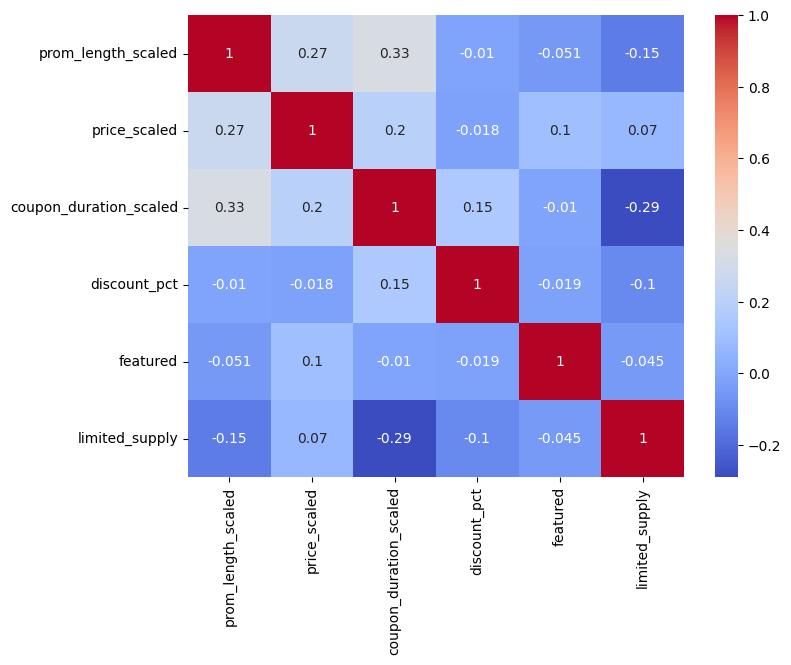

In [77]:
feature_cols = [col + '_scaled' for col in update_cols] + ['min_req','discount_pct','featured','limited_supply']
feature_cols.remove('quantity_sold_scaled')
feature_cols.remove('min_req')
feature_cols.remove('fb_likes_scaled')
feature_cols.remove('revenue_scaled')
corr = df_groupon[feature_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()
# >0.7 moderat, >0.9 serious

In [78]:
# Variance inflation factor to check multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = df_groupon[feature_cols].copy()
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()
vif_df = pd.DataFrame()
vif_df['feature'] = X_vif.columns
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_df)
# <5, okay, 5-10, moderate, >10 serious

                  feature       VIF
0      prom_length_scaled  1.190350
1            price_scaled  1.139176
2  coupon_duration_scaled  1.255968
3            discount_pct  5.753748
4                featured  1.148202
5          limited_supply  5.663296


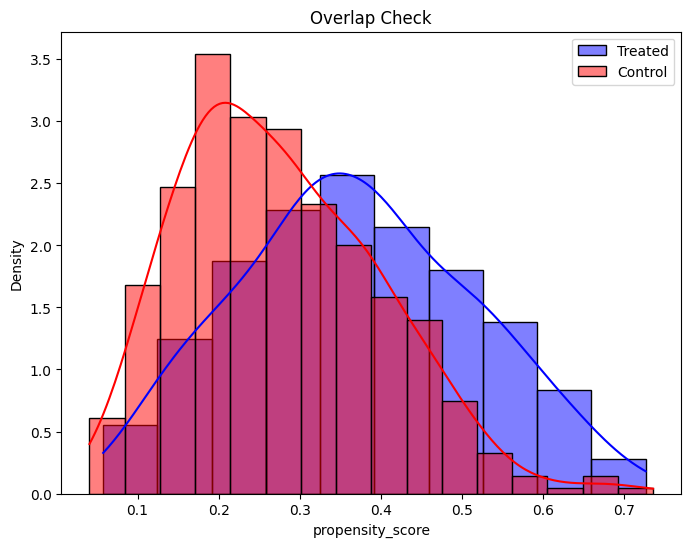

In [79]:
# train model
from sklearn.linear_model import LogisticRegression
X = df_groupon[feature_cols]
y = df_groupon['treatment']
ps_model = LogisticRegression()
ps_model.fit(X,y)
df_groupon['propensity_score'] = ps_model.predict_proba(X)[:,1]
# check overlap
treated = df_groupon[(df_groupon['treatment']==1)]
control = df_groupon[(df_groupon['treatment']==0)]
plt.figure(figsize=(8,6))
sns.histplot(treated['propensity_score'], color='blue', label='Treated', kde=True, stat='density')  
sns.histplot(control['propensity_score'], color='red', label='Control', kde=True, stat='density')
plt.title('Overlap Check')
plt.legend()
plt.show()

this chart is showing treated near 1 control near 0: matching unreliable

In [80]:
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])
distances, indices = nn.kneighbors(treated[['propensity_score']])
matched_control = control.iloc[indices.flatten()].reset_index(drop=True)
matched_df = pd.concat([treated.reset_index(drop=True), matched_control], ignore_index=True)
df_groupon.groupby('treatment')[feature_cols].mean()

,prom_length_scaled,price_scaled,coupon_duration_scaled,discount_pct,featured,limited_supply
treatment,,,,,,
0,0.113987,0.094219,-0.081352,52.973684,0.105263,0.852227
1,-0.260692,-0.215483,0.186056,53.263889,0.143519,0.777778


In [81]:
matched_df.groupby('treatment')[feature_cols].mean()

,prom_length_scaled,price_scaled,coupon_duration_scaled,discount_pct,featured,limited_supply
treatment,,,,,,
0,-0.186127,-0.212163,0.237506,54.097222,0.157407,0.726852
1,-0.260692,-0.215483,0.186056,53.263889,0.143519,0.777778


In [82]:
# validate balance with standardized mean difference
def smd(df, treatment_col, feature):
    treated = matched_df[matched_df[treatment_col]==1][feature]
    control = matched_df[matched_df[treatment_col]==0][feature]
    return (treated.mean() - control.mean()) / np.sqrt((treated.var() + control.var()) / 2)

for col in feature_cols:
    print(f"SMD for {col}: {smd(matched_df, 'treatment', col):.2f}")
# <0.2, excellent, <0.2 acceptable, >0.25 imbalance concern

SMD for prom_length_scaled: -0.08
SMD for price_scaled: -0.00
SMD for coupon_duration_scaled: -0.05
SMD for discount_pct: -0.12
SMD for featured: -0.04
SMD for limited_supply: 0.12


<Axes: xlabel='fb_likes_scaled', ylabel='Count'>

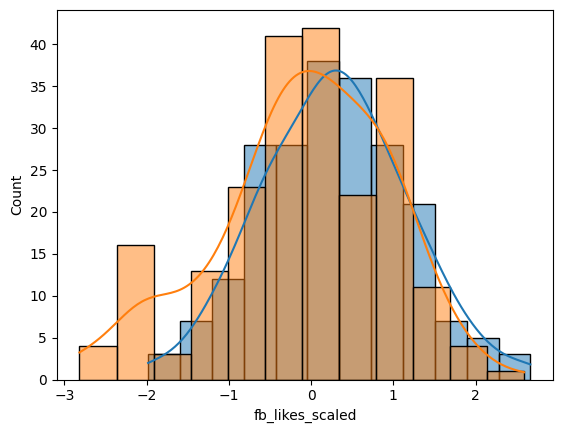

In [83]:
sns.histplot(matched_df[matched_df['treatment']==1]['fb_likes_scaled'], kde=True)
sns.histplot(matched_df[matched_df['treatment']==0]['fb_likes_scaled'], kde=True)

<Axes: xlabel='revenue_scaled', ylabel='Density'>

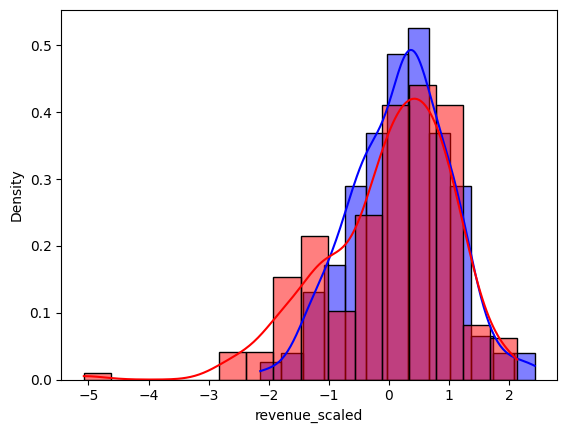

In [84]:
sns.histplot(matched_df[matched_df['treatment']==1]['revenue_scaled'], color='blue', label='Treated', kde=True, stat='density')
sns.histplot(matched_df[matched_df['treatment']==0]['revenue_scaled'], color='red', label='Control', kde=True, stat='density')

In [85]:
# since scaled metrics are approximately normal, use t test
from scipy.stats import ttest_ind
treated_outcome = matched_df[
    matched_df["treatment"] == 1
]["revenue_scaled"]
control_outcome = matched_df[
    matched_df["treatment"] == 0
]["revenue_scaled"]
t_stat, p_value = ttest_ind(
    treated_outcome, control_outcome, equal_var=False
)
print(p_value)

0.022095862444745235


In [86]:
treated_outcome = matched_df[matched_df['treatment']==1]['fb_likes_scaled']
control_outcome = matched_df[matched_df['treatment']==0]['fb_likes_scaled']
t_stat, p_value = ttest_ind(
    treated_outcome, control_outcome, equal_var=False
)
print(p_value)

0.000122860715832113
